https://datos.bancomundial.org/indicador/SP.POP.GROW?locations=AR

In [1]:
import matplotlib.pyplot as plt
import scipy
from io import StringIO
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [2]:
datos = StringIO(""""Country Name","Country Code","Indicator Name","Indicator Code","1960","1961","1962","1963","1964","1965","1966","1967","1968","1969","1970","1971","1972","1973","1974","1975","1976","1977","1978","1979","1980","1981","1982","1983","1984","1985","1986","1987","1988","1989","1990","1991","1992","1993","1994","1995","1996","1997","1998","1999","2000","2001","2002","2003","2004","2005","2006","2007","2008","2009","2010","2011","2012","2013","2014","2015","2016","2017","2018","2019","2020","2021","2022","2023","2024","2025"\n
"Argentina","ARG","Crecimiento de la población (%) anual","SP.POP.GROW","","1.65516691395024","1.65684089054911","1.64339841718671","1.61030882522813","1.56411446631364","1.53151134539948","1.52552564515699","1.5300700621594","1.53510695155484","1.56001941277121","1.57425828869798","1.58329622607322","1.61675611830692","1.64473215761616","1.60810835620248","1.56523230766791","1.58361041281169","1.59885003313826","1.59684779867466","1.59304228632554","1.60201232076144","1.60420679867482","1.6019042448548","1.59235691940308","1.57262930146869","1.55539122422629","1.54512926233209","1.54990330404865","1.53134817062707","1.49157462934909","1.43788006980649","1.38438120034139","1.35364018555542","1.3401375748685","1.3103115077878","1.25745217924583","1.21464795933597","1.17552563201514","1.15304317167294","1.13312807570195","1.09794672757946","1.06941318335345","1.0331399769648","1.01407652046238","1.02745772191722","1.02824760534561","0.991101935066697","1.01288878477428","1.05977470732485","1.05636332156278","1.06474009749784","1.0276613644946","0.992958989681133","1.0317435786984","1.04725888735726","0.968911125580978","0.881249595012674","0.822969480473088","0.710900853077743","0.484665636741261","0.265879395046274","0.210808731072658","0.286976121920089","0.345829819817895","0.339100654860035"
""")
series = pd.read_csv(datos)
series = series.drop(columns=["Country Name", "Indicator Name", "Indicator Code"])
series = pd.melt(series, id_vars=['Country Code'], var_name='año', value_name='crecimiento_anual')
series["año"] = series["año"].astype(int)
series = series[series["crecimiento_anual"].notna()]
series.head()

,Country Code,año,crecimiento_anual
1,ARG,1961,1.655167
2,ARG,1962,1.656841
3,ARG,1963,1.643398
4,ARG,1964,1.610309
5,ARG,1965,1.564114


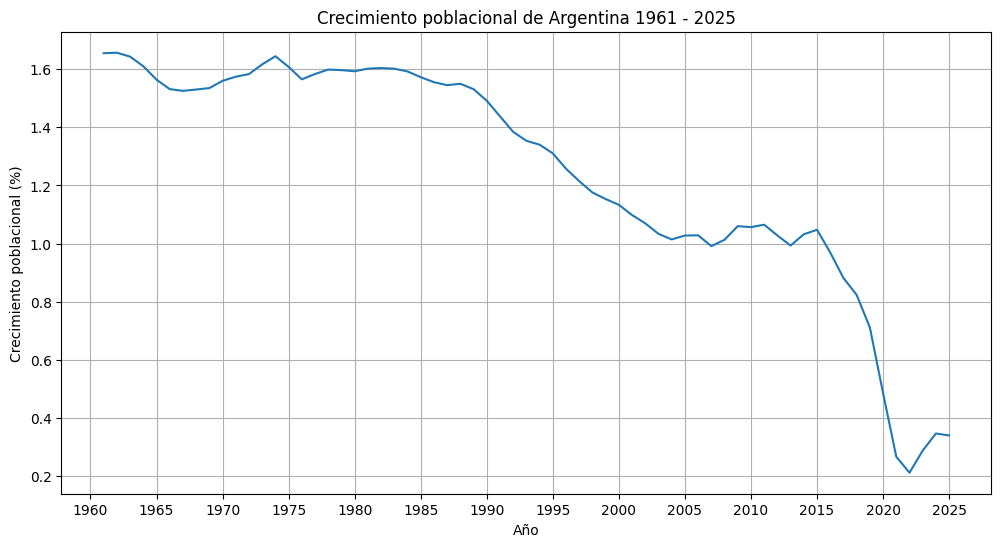

In [3]:
plt.figure(figsize=(12, 6))

plt.plot(series["año"], series["crecimiento_anual"])
plt.title(f"Crecimiento poblacional de Argentina {min(series['año'])} - {max(series['año'])}")
plt.xlabel("Año")
plt.ylabel("Crecimiento poblacional (%)")
plt.xticks([i for i in range(min(series["año"])-1, max(series["año"]) + 1, 5)])
plt.grid()

In [4]:
series["sma_3"] = series["crecimiento_anual"].rolling(window=3, center=False).mean()
series["std_3"] = series["crecimiento_anual"].rolling(window=3, center=False).std()

series["ewma_3"] = series["crecimiento_anual"].ewm(span=3, adjust=True).mean()


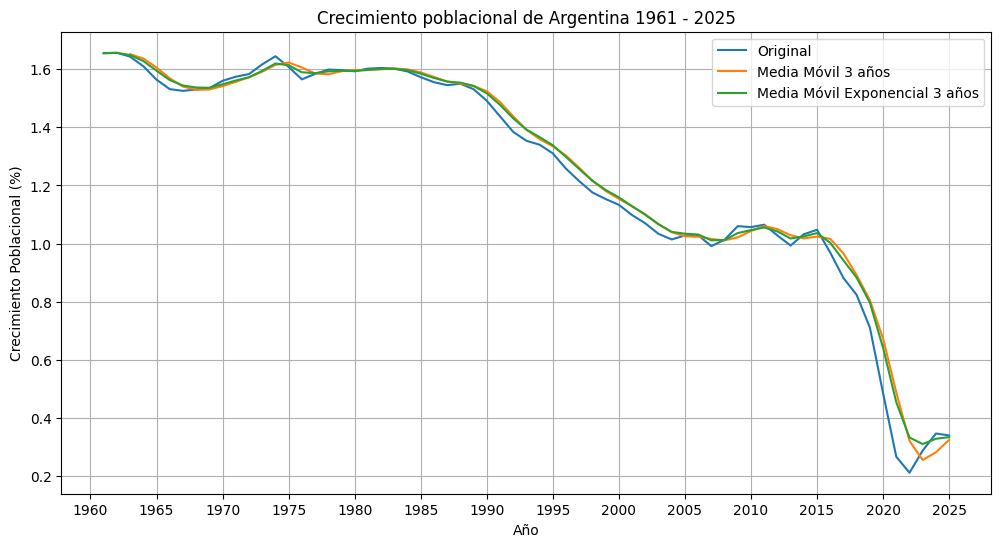

In [5]:
plt.figure(figsize=(12, 6))

plt.plot(series["año"], series["crecimiento_anual"])
plt.plot(series["año"], series["sma_3"])

plt.plot(series["año"], series["ewma_3"])

plt.legend(["Original", "Media Móvil 3 años",  "Media Móvil Exponencial 3 años",
            # "Tendencia Lineal",
            # "Ruido"
            ])
plt.title(f"Crecimiento poblacional de Argentina {min(series['año'])} - {max(series['año'])}")
plt.xlabel("Año")
plt.ylabel("Crecimiento Poblacional (%)")
plt.xticks([i for i in range(min(series["año"])-1, max(series["año"]) + 1, 5)])
plt.grid()

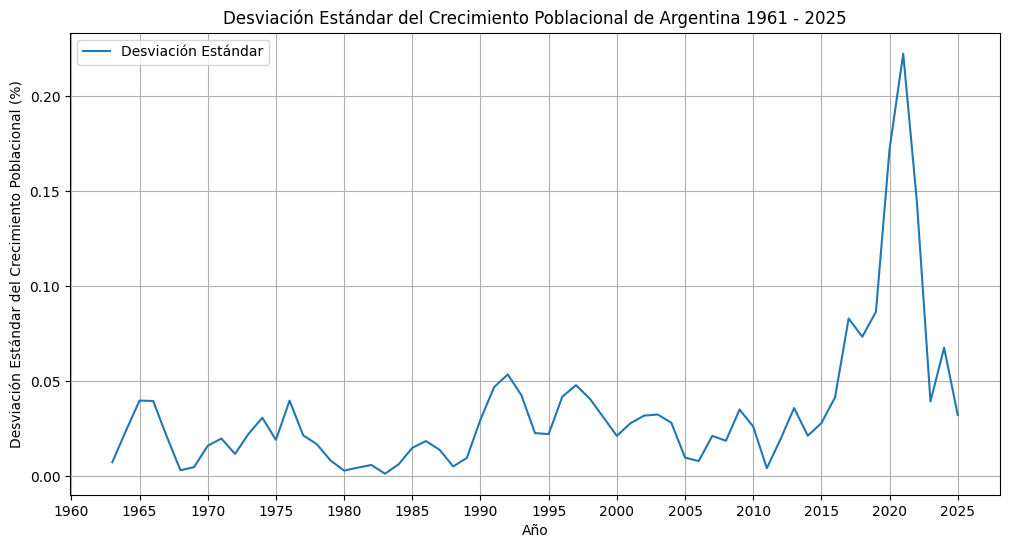

In [6]:
plt.figure(figsize=(12, 6))

plt.plot(series["año"], series["std_3"])
plt.legend(["Desviación Estándar"])
plt.title(f"Desviación Estándar del Crecimiento Poblacional de Argentina {min(series['año'])} - {max(series['año'])}")
plt.xlabel("Año")
plt.ylabel("Desviación Estándar del Crecimiento Poblacional (%)")
plt.xticks([i for i in range(min(series["año"])-1, max(series["año"]) + 1, 5)])
plt.grid()

Dado que la serie tiene errores multiplicativos, se transforma a escala logarítmica usando el logaritmo en base 10.

Se ajustan polinomios de grados 0 a 10 y se evalua el coeficiente de determinación para decidir en función de un balance de
bondad de ajuste y parsimonia. 

In [38]:
series["crecimiento_anual_log"] = np.log10(series["crecimiento_anual"])

ajustes = []
# plt.plot(series["año"], series["crecimiento_anual_log"], label="Crecimiento poblacional (log10)")
for degree in range(0, 11):
    coefficients = np.polyfit(series["año"], series["crecimiento_anual_log"], deg=degree)
    series[f"trend_poly_{degree}_log"] = np.polyval(coefficients, series["año"])
    # plt.plot(series["año"], trend, label=f"Tendencia Polinómica Grado {degree}")

    residuals = series["crecimiento_anual_log"] - series[f"trend_poly_{degree}_log"]
    rss = np.sum(residuals**2)
    tss = np.sum((series["crecimiento_anual_log"] - np.mean(series["crecimiento_anual_log"])) ** 2)
    r2 = 1 - (rss / tss)
    # print(f"R^2({degree}): {r2}")
    ajustes.append((degree, r2))
# plt.legend()

df_ajustes = pd.DataFrame(ajustes, columns=["Grado del Polinomio", "R^2"])
df_ajustes

/tmp/ipykernel_8591/3681618376.py:6: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(series["año"], series["crecimiento_anual_log"], deg=degree)
/tmp/ipykernel_8591/3681618376.py:6: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(series["año"], series["crecimiento_anual_log"], deg=degree)
/tmp/ipykernel_8591/3681618376.py:6: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(series["año"], series["crecimiento_anual_log"], deg=degree)
/tmp/ipykernel_8591/3681618376.py:6: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(series["año"], series["crecimiento_anual_log"], deg=degree)
/tmp/ipykernel_8591/3681618376.py:6: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(series["año"], series["crecimiento_anual_log"], deg=degree)


,Grado del Polinomio,R^2
0,0,0.000000
1,1,0.627244
2,2,0.823485
3,3,0.865721
4,4,0.890420
5,5,0.906659
6,6,0.906600
7,7,0.910083
8,8,0.910149
9,9,0.910225


Se grafican los ajustes hasta el polinomio de grado 5 inclusive. Si bien para grados mayores el coeficiente de determinación aumenta, se prefiere un ajuste más simple.

/tmp/ipykernel_8591/2860527477.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  r2 = float(df_ajustes[df_ajustes["Grado del Polinomio"]==degree]["R^2"])


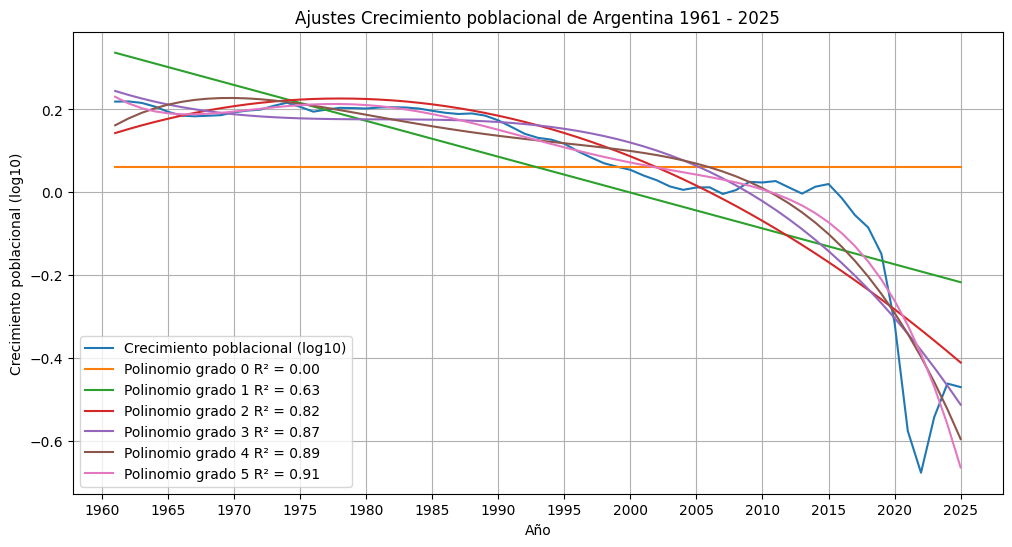

In [46]:
plt.figure(figsize=(12, 6))
plt.plot(series["año"], series["crecimiento_anual_log"], label="Crecimiento poblacional (log10)")
for degree in range(0, 6):
    r2 = float(df_ajustes[df_ajustes["Grado del Polinomio"]==degree]["R^2"])
    plt.plot(series["año"], series[f"trend_poly_{degree}_log"], label=f"Polinomio grado {degree} R² = {r2:.2f}")
plt.title(f"Ajustes Crecimiento poblacional de Argentina {min(series['año'])} - {max(series['año'])}")
plt.xlabel("Año")
plt.ylabel("Crecimiento poblacional (log10)")
plt.xticks([i for i in range(min(series["año"])-1, max(series["año"]) + 1, 5)])
plt.grid()
plt.legend()
plt.show()

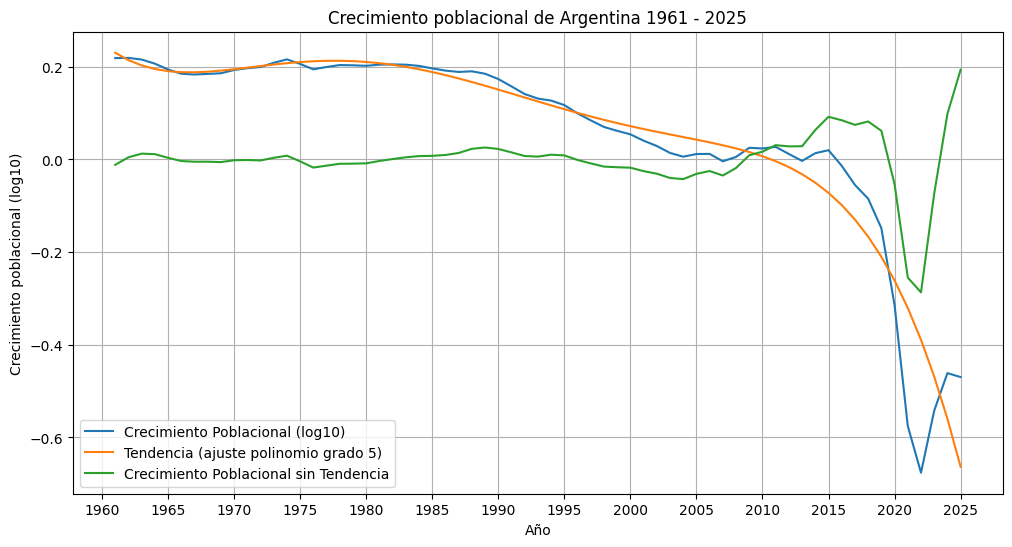

In [52]:

plt.figure(figsize=(12, 6))


plt.plot(series["año"], series["crecimiento_anual_log"], label="Crecimiento Poblacional (log10)")
plt.plot(series["año"], series["trend_poly_5_log"], label="Tendencia (ajuste polinomio grado 5)")

plt.plot(series["año"], series["detrend_poly_5_log"], label="Crecimiento Poblacional sin Tendencia")
plt.legend()
plt.title(f"Crecimiento poblacional de Argentina {min(series['año'])} - {max(series['año'])}")
plt.xlabel("Año")
plt.ylabel("Crecimiento poblacional (log10)")
plt.xticks([i for i in range(min(series["año"])-1, max(series["año"]) + 1, 5)])
plt.grid()
plt.show()

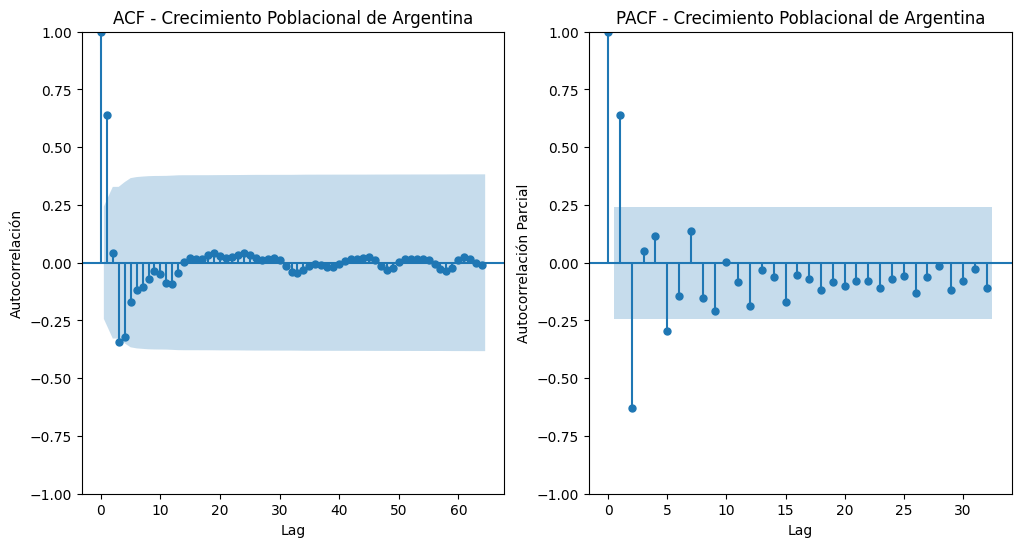

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sm.graphics.tsa.plot_acf(series["detrend_poly_5_log"], lags=len(series["detrend_poly_5_log"])-1, ax=axes[0])
sm.graphics.tsa.plot_pacf(series["detrend_poly_5_log"], lags=32, ax=axes[1])
axes[0].set_title("ACF - Crecimiento Poblacional de Argentina")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Autocorrelación")
axes[1].set_title("PACF - Crecimiento Poblacional de Argentina")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Autocorrelación Parcial")
plt.show()

La función de autocorrelación parcial indica que los lags 1, 2 y 5 son significativos. Para construir un modelo autoregresivo 
se podriann usar los dos años anteriores.